# Decision Tree Classifier — Loan Approval

**Learning intentions:**
- Train a `DecisionTreeClassifier` on a small labelled dataset
- Visualise the trained tree using graphviz
- Trace a prediction path through the tree
- Explore the effect of `max_depth` on model complexity

**Tiered tasks:**
- **Core** — complete all cells up to and including the trace task
- **Extended** — also complete the `max_depth` investigation
- **Advanced** — also add a second feature and compare trees

## Setup

Run this cell first. It imports all required libraries.

In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1 — Load the dataset

This dataset contains historical loan applications. Each row is one applicant.

| Feature | Description |
|---|---|
| `income_k` | Annual income in thousands of dollars |
| `credit_score` | Credit score (300–850) |
| `approved` | 1 = loan approved, 0 = loan declined (the label) |

    income_k  credit_score  approved
0         25           550         0
1         30           600         0
2         28           580         0
3         35           650         1
4         32           610         0
5         27           560         0
6         38           680         1
7         22           540         0
8         36           640         1
9         34           630         0
10        45           620         0
11        50           700         1
12        48           650         0
13        52           740         1
14        42           600         0
15        47           690         1
16        51           720         1
17        49           700         1
18        55           680         0
19        43           665         1
20        60           700         1
21        65           740         1
22        62           720         1
23        70           780         1
24        58           660         0
25        68           760         1
2

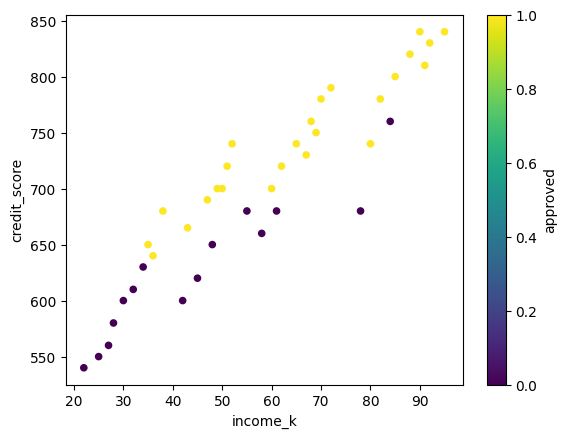

In [3]:
data = {
    'income_k':     [25, 30, 28, 35, 32, 27, 38, 22, 36, 34, 45, 50, 48, 52, 42, 47, 51, 49, 55, 43, 60, 65, 62, 70, 58, 68, 72, 67, 61, 69, 80, 85, 82, 90, 78, 88, 95, 92, 84, 91],
    'credit_score': [550, 600, 580, 650, 610, 560, 680, 540, 640, 630, 620, 700, 650, 740, 600, 690, 720, 700, 680, 665, 700, 740, 720, 780, 660, 760, 790, 730, 680, 750, 740, 800, 780, 840, 680, 820, 840, 830, 760, 810],
    'approved':     [0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1]
}

df = pd.DataFrame(data)
print(df)
print(f"\nApproved: {df['approved'].sum()}  |  Declined: {(df['approved'] == 0).sum()}")

# Lets visualise the training data too
df.sort_values('income_k').plot(kind='scatter',x='income_k', y='credit_score',c='approved', cmap='viridis')
plt.show()

**Q1 (answer in the cell below):** Looking at the data, what pattern do you notice between income/credit score and loan approval? Write a prediction before training.

*Your answer here:*

## 2 — Prepare features and labels

In [4]:
# X contains the input features (what the model uses to make a decision)
X = df[['income_k', 'credit_score']]

# y contains the labels (what the model is trying to predict)
y = df['approved']

print("Features (X):")
print(X.head())
print("\nLabels (y):")
print(y.head())

Features (X):
   income_k  credit_score
0        25           550
1        30           600
2        28           580
3        35           650
4        32           610

Labels (y):
0    0
1    0
2    0
3    1
4    0
Name: approved, dtype: int64


## 3 — Train the model

In [5]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)

print("Model trained.")
print(f"Tree depth: {model.get_depth()}")
print(f"Number of leaves: {model.get_n_leaves()}")

Model trained.
Tree depth: 3
Number of leaves: 6


**Q2:** What does `fit()` do? What information does the model store after fitting?

*Your answer here:*

## 4 — Visualise the tree

In [6]:
# Text representation
tree_text = export_text(model, feature_names=['income_k', 'credit_score'])
print(tree_text)

|--- credit_score <= 685.00
|   |--- credit_score <= 635.00
|   |   |--- class: 0
|   |--- credit_score >  635.00
|   |   |--- income_k <= 45.50
|   |   |   |--- class: 1
|   |   |--- income_k >  45.50
|   |   |   |--- class: 0
|--- credit_score >  685.00
|   |--- income_k <= 83.00
|   |   |--- class: 1
|   |--- income_k >  83.00
|   |   |--- credit_score <= 780.00
|   |   |   |--- class: 0
|   |   |--- credit_score >  780.00
|   |   |   |--- class: 1



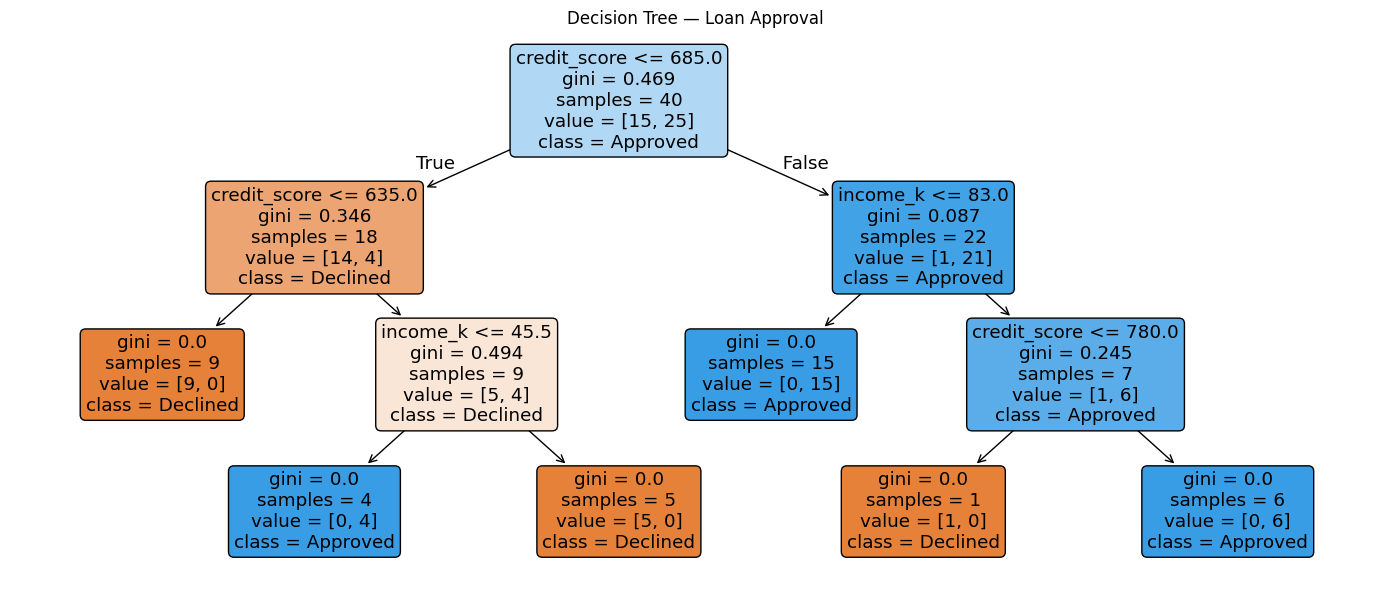

In [7]:
# Graphical representation
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(
    model,
    feature_names=['income_k', 'credit_score'],
    class_names=['Declined', 'Approved'],
    filled=True,
    rounded=True,
    ax=ax
)
plt.title("Decision Tree — Loan Approval")
plt.tight_layout()
plt.show()

## 5 — Trace a prediction path  *(Core task)*

Use the tree printed above to manually trace the prediction for the applicant below.

Write each node condition, whether it is True or False, and the branch you follow.

In [8]:
# Applicant to trace
applicant = pd.DataFrame({'income_k': [52], 'credit_score': [680]})

prediction = model.predict(applicant)
print(f"Model prediction: {'Approved' if prediction[0] == 1 else 'Declined'}")

Model prediction: Declined


**Trace task:** In the cell below, write out each decision node the model visits for this applicant. Format it like this:

```
Node 1: income_k <= 47.5?  →  False (52 > 47.5)  →  go right
Node 2: ...
Final prediction: ...
```

*Your trace here:*

## 6 — Investigate max_depth  *(Extended task)*

Retrain the model with different values of `max_depth`. Observe how the tree changes.

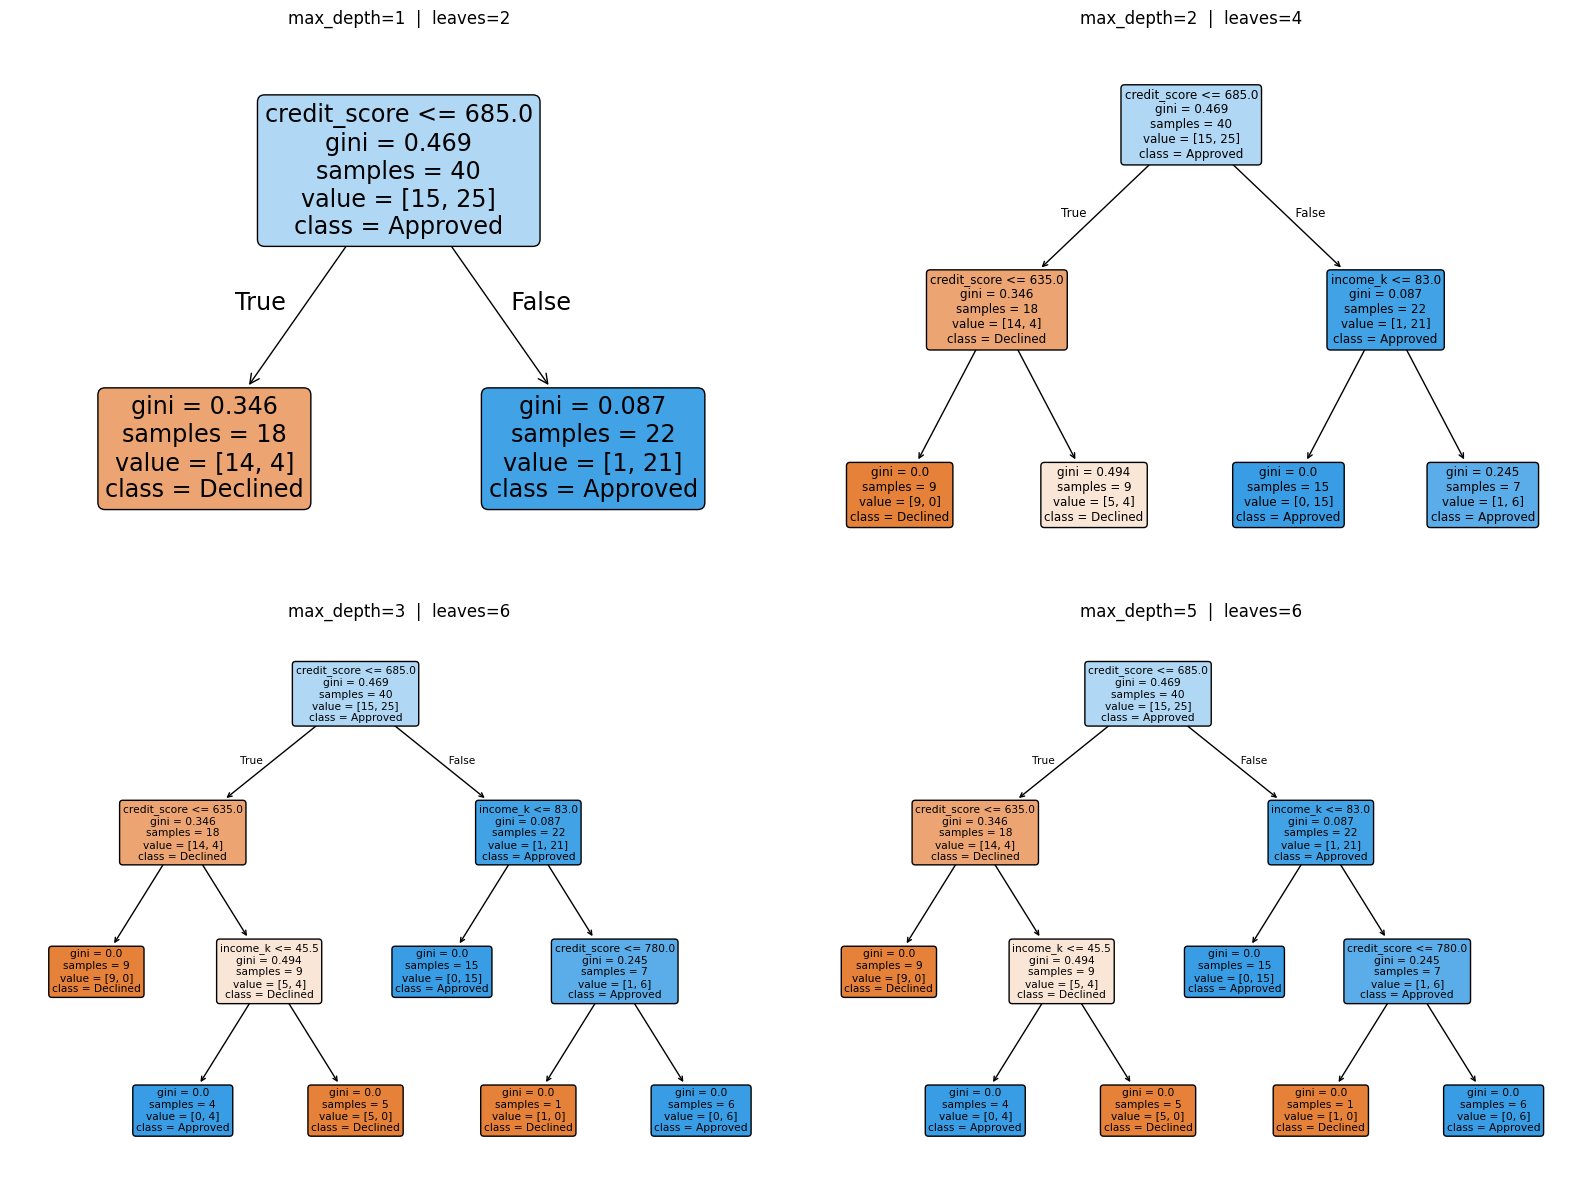

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # Flatten to easily iterate

for ax, depth in zip(axes, [1, 2, 3, 5]):
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X, y)
    plot_tree(
        m,
        feature_names=['income_k', 'credit_score'],
        class_names=['Declined', 'Approved'],
        filled=True,
        rounded=True,
        ax=ax
    )
    ax.set_title(f"max_depth={depth}  |  leaves={m.get_n_leaves()}")

plt.tight_layout()
plt.show()

**Q3:** Describe the effect of increasing `max_depth`. What happens to the number of leaves? What risk does a very deep tree introduce?

*Your answer here:*

## 7 — Add a second feature  *(Advanced task)*

A third feature — `employment_years` — has been added to the dataset.

Retrain the model with all three features and compare the new tree to the original two-feature tree.

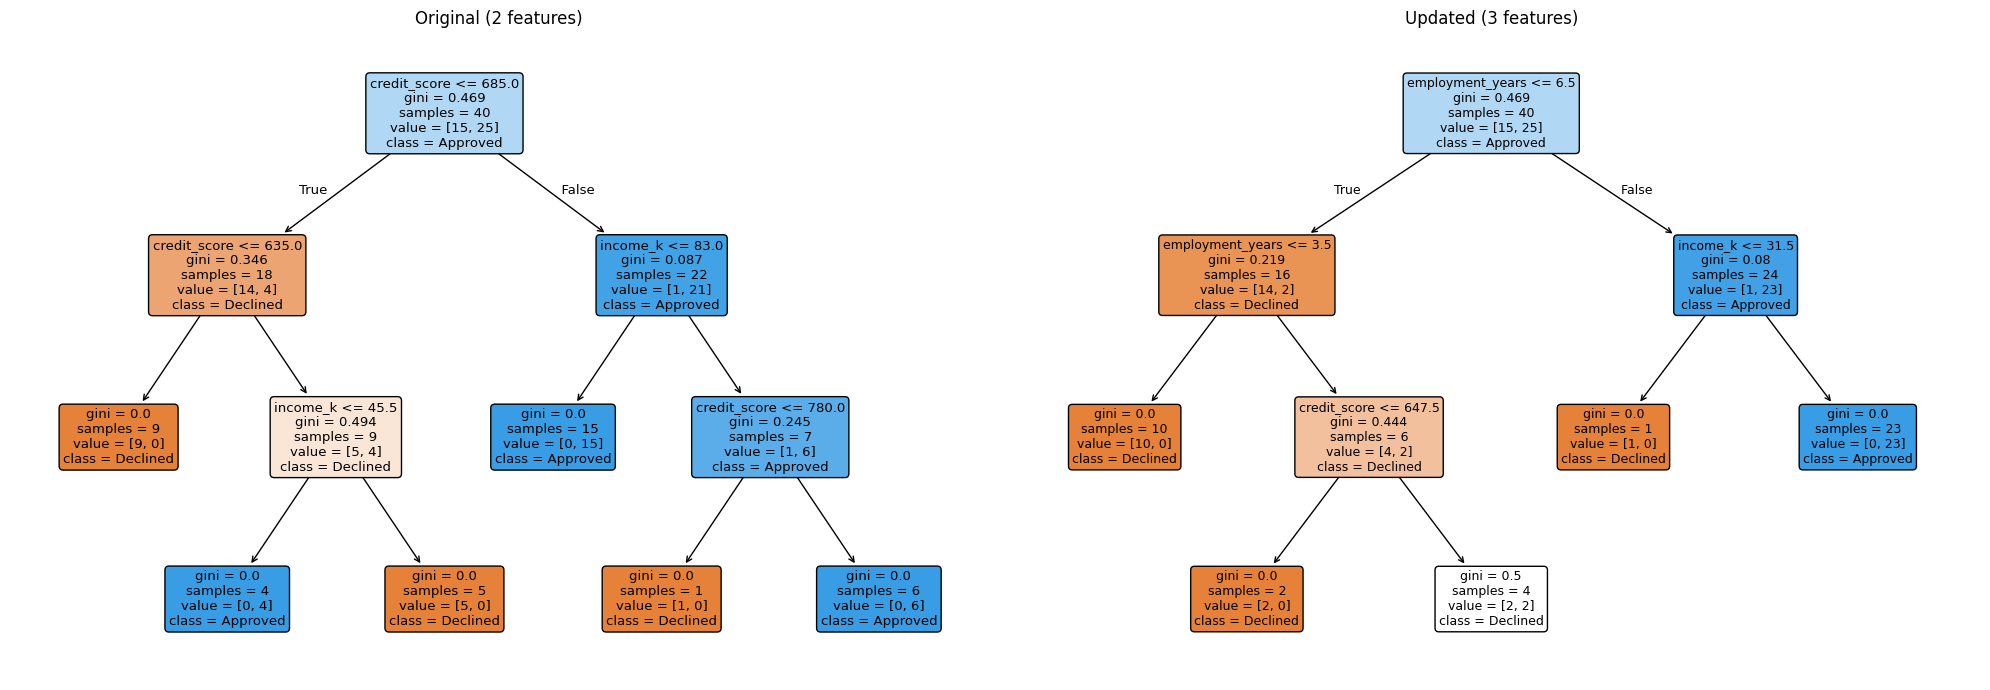

In [12]:
# Add employment_years to the dataframe
df['employment_years'] = [2, 3, 8, 10, 4, 1, 12, 1, 9, 5, 3, 11, 2, 14, 1, 8, 13, 10, 6, 4, 7, 12, 9, 15, 2, 11, 14, 10, 3, 8, 6, 13, 11, 16, 2, 12, 15, 14, 5, 10]

X2 = df[['income_k', 'credit_score', 'employment_years']]

model2 = DecisionTreeClassifier(max_depth=3, random_state=42)
model2.fit(X2, y)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

plot_tree(model, feature_names=['income_k', 'credit_score'],
          class_names=['Declined', 'Approved'], filled=True, rounded=True, ax=axes[0])
axes[0].set_title("Original (2 features)")

plot_tree(model2, feature_names=['income_k', 'credit_score', 'employment_years'],
          class_names=['Declined', 'Approved'], filled=True, rounded=True, ax=axes[1])
axes[1].set_title("Updated (3 features)")

plt.tight_layout()
plt.show()

**Q4:** Compare the two trees. Did `employment_years` appear as a split in the new tree? What does this tell you about how the decision tree selects which features to use?

*Your answer here:*

---
## Reflection

1. In your own words, explain how a decision tree makes a prediction.

2. What is the risk of setting `max_depth` too high? What is the risk of setting it too low?

3. This dataset has only 15 rows. What limitations does this place on the model?